# Football World Cup KPIs
Data sourced from `foot_etl.sqlite` — star schema: `match`, `team`, `stadium`, `city`, `edition`.

In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

DB = "foot_etl.sqlite"
con = sqlite3.connect(DB)
print("Connected to", DB)


Connected to foot_etl.sqlite


In [9]:
# ── Load unified match view (all editions) ───────────────────────────────────
matches = pd.read_sql("""
    SELECT
        m.id_match,
        m.date,
        m.round,
        m.home_result,
        m.away_result,
        m.result,
        ht.team_name  AS home_team,
        at.team_name  AS away_team,
        s.stadium_name,
        c.city_name,
        e.year        AS edition_year,
        e.edition_name
    FROM match m
    JOIN team    ht ON ht.id_team   = m.id_home_team
    JOIN team    at ON at.id_team   = m.id_away_team
    JOIN stadium s  ON s.id_stadium = m.id_stadium
    JOIN city    c  ON c.id_city    = s.id_city
    JOIN edition e  ON e.id_edition = m.id_edition
    ORDER BY m.id_match
""", con)

matches["total_goals"] = matches["home_result"] + matches["away_result"]
print(f"Total matches: {len(matches)} | Editions: {matches['edition_year'].nunique()}")
print(matches.groupby("edition_year").size().to_string())


Total matches: 900 | Editions: 21
edition_year
1930    18
1934    17
1938    18
1950    22
1954    26
1958    35
1962    32
1966    32
1970    32
1974    38
1978    38
1982    52
1986    52
1990    52
1994    52
1998    64
2002    64
2006    64
2010    64
2014    64
2022    64


## KPI 1 — Average goals per match by edition (1930–2022)

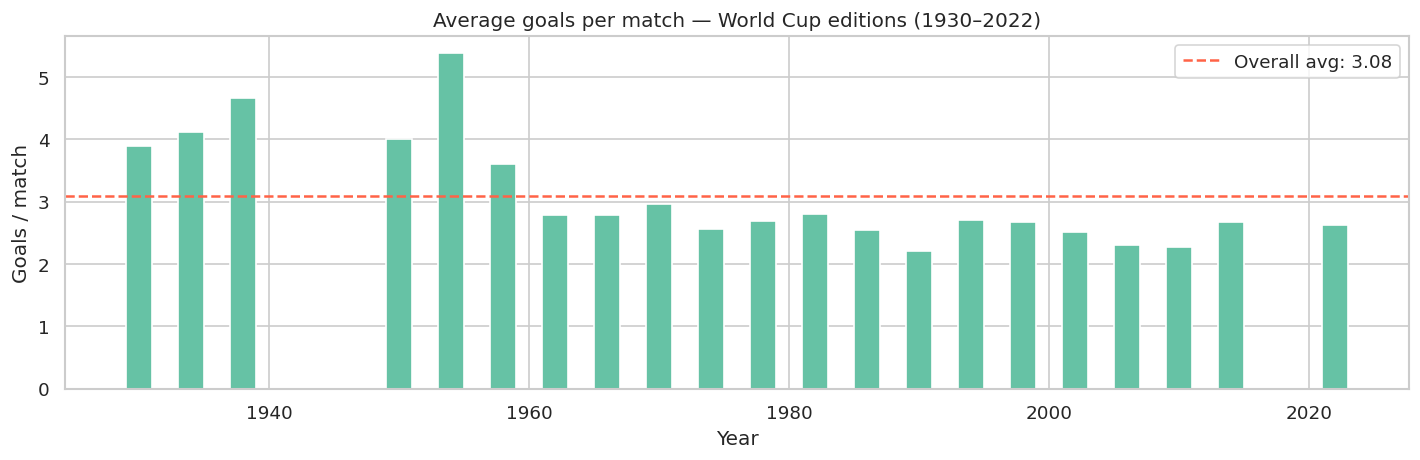

              goals  n_matches  goals_per_match
edition_year                                   
1930           70.0         18         3.888889
1934           70.0         17         4.117647
1938           84.0         18         4.666667
1950           88.0         22         4.000000
1954          140.0         26         5.384615
1958          126.0         35         3.600000
1962           89.0         32         2.781250
1966           89.0         32         2.781250
1970           95.0         32         2.968750
1974           97.0         38         2.552632
1978          102.0         38         2.684211
1982          146.0         52         2.807692
1986          132.0         52         2.538462
1990          115.0         52         2.211538
1994          141.0         52         2.711538
1998          171.0         64         2.671875
2002          161.0         64         2.515625
2006          147.0         64         2.296875
2010          145.0         64         2

In [10]:
gpm = (
    matches.groupby("edition_year")["total_goals"]
    .agg(goals="sum", n_matches="count")
    .assign(goals_per_match=lambda d: d["goals"] / d["n_matches"])
)

avg = gpm["goals_per_match"].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(gpm.index, gpm["goals_per_match"], width=2, color=sns.color_palette("Set2")[0])
ax.axhline(avg, color="tomato", linestyle="--", label=f"Overall avg: {avg:.2f}")
ax.set(title="Average goals per match — World Cup editions (1930–2022)",
       xlabel="Year", ylabel="Goals / match")
ax.legend()
plt.tight_layout()
plt.show()

print(gpm.to_string())


## KPI 2 — Top 15 teams by total goals scored (all editions)

/tmp/ipykernel_55834/1466951624.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scorers.values, y=top_scorers.index, ax=ax, palette="Set2")


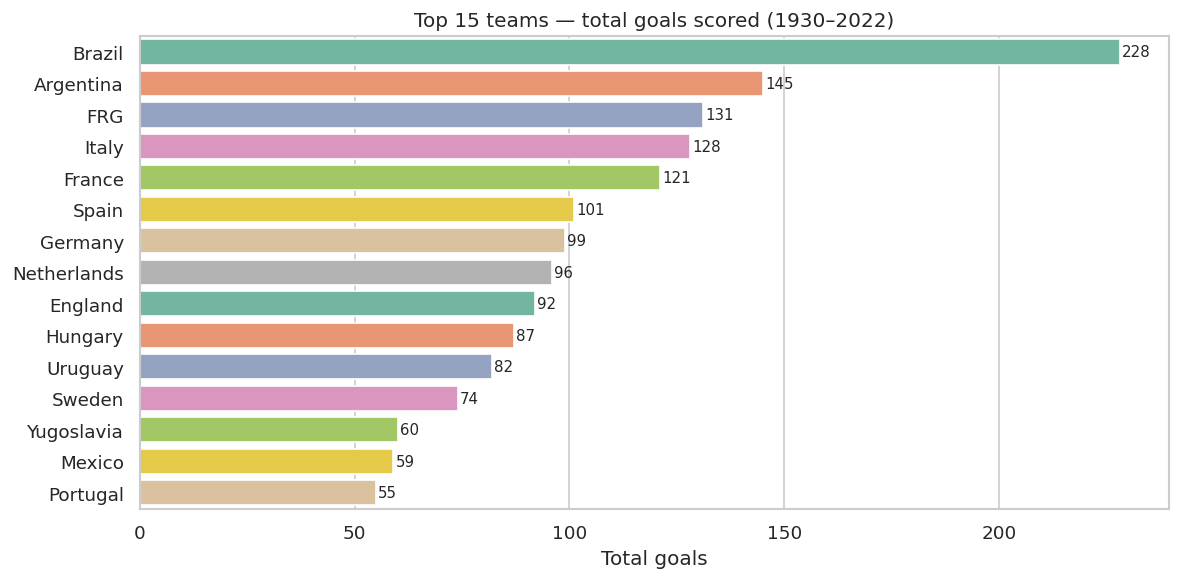

In [11]:
home_goals = matches.groupby("home_team")["home_result"].sum().rename("goals")
away_goals = matches.groupby("away_team")["away_result"].sum().rename("goals")

top_scorers = (
    pd.concat([home_goals, away_goals])
    .groupby(level=0).sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_scorers.values, y=top_scorers.index, ax=ax, palette="Set2")
ax.set(title="Top 15 teams — total goals scored (1930–2022)",
       xlabel="Total goals", ylabel="")
for i, v in enumerate(top_scorers.values):
    ax.text(v + 0.5, i, str(int(v)), va="center", fontsize=9)
plt.tight_layout()
plt.show()


## KPI 3 — Win / Draw / Loss record & win rate — top 10 teams (all editions)

/tmp/ipykernel_55834/678968958.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10["win_rate"], y=top10.index, ax=axes[1], palette="Blues_r")


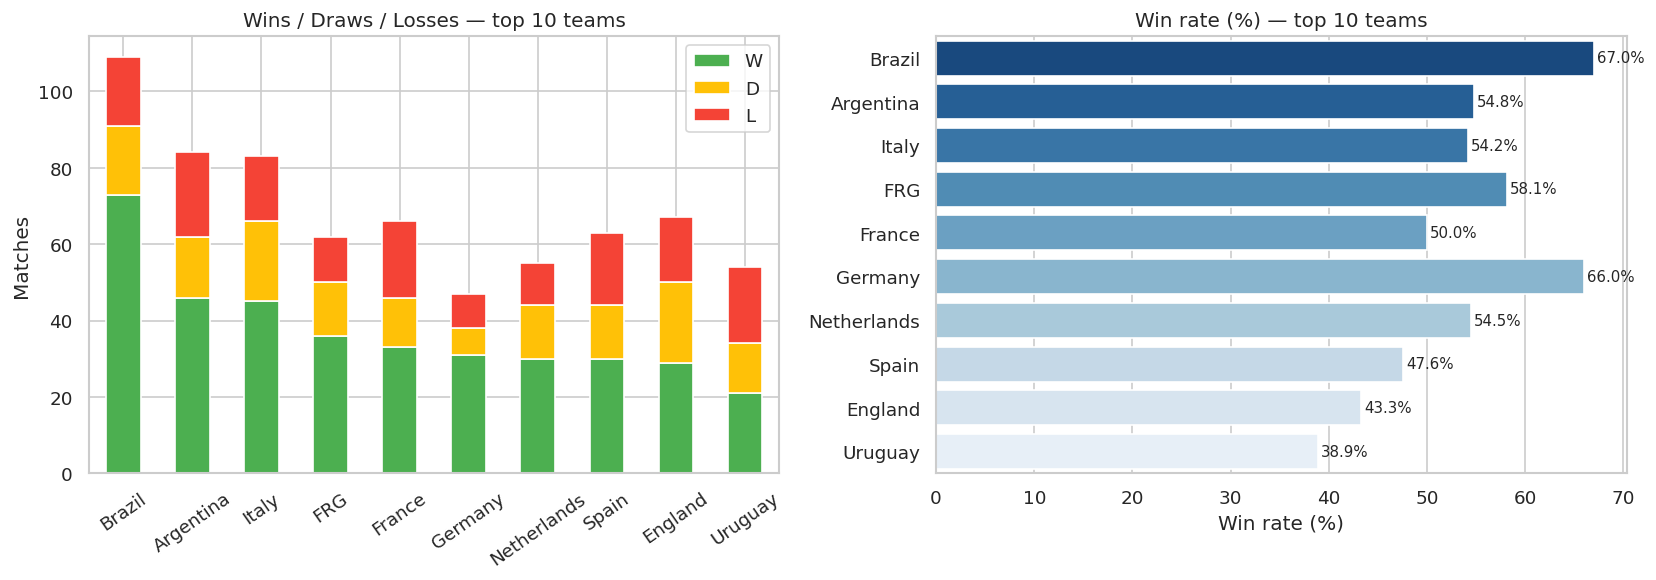

outcome       W   D   L  played  win_rate
team                                     
Brazil       73  18  18     109      67.0
Argentina    46  16  22      84      54.8
Italy        45  21  17      83      54.2
FRG          36  14  12      62      58.1
France       33  13  20      66      50.0
Germany      31   7   9      47      66.0
Netherlands  30  14  11      55      54.5
Spain        30  14  19      63      47.6
England      29  21  17      67      43.3
Uruguay      21  13  20      54      38.9


In [12]:
# result column: "home" = home team won, "away" = away team won, "draw"
home_results = matches.assign(
    team=matches["home_team"],
    outcome=matches["result"].map({"home": "W", "away": "L", "draw": "D"})
)[["team", "outcome"]]

away_results = matches.assign(
    team=matches["away_team"],
    outcome=matches["result"].map({"away": "W", "home": "L", "draw": "D"})
)[["team", "outcome"]]

rec = pd.concat([home_results, away_results], ignore_index=True)

kpi_wins = (
    rec.groupby(["team", "outcome"]).size().unstack(fill_value=0)
    .reindex(columns=["W", "D", "L"], fill_value=0)
)
kpi_wins["played"]   = kpi_wins.sum(axis=1)
kpi_wins["win_rate"] = (kpi_wins["W"] / kpi_wins["played"] * 100).round(1)

top10 = kpi_wins.nlargest(10, "W")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top10[["W", "D", "L"]].plot(kind="bar", stacked=True, ax=axes[0],
                             color=["#4CAF50", "#FFC107", "#F44336"],
                             edgecolor="white")
axes[0].set(title="Wins / Draws / Losses — top 10 teams", xlabel="", ylabel="Matches")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(loc="upper right")

sns.barplot(x=top10["win_rate"], y=top10.index, ax=axes[1], palette="Blues_r")
axes[1].set(title="Win rate (%) — top 10 teams", xlabel="Win rate (%)", ylabel="")
for i, v in enumerate(top10["win_rate"]):
    axes[1].text(v + 0.3, i, f"{v}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()
print(top10[["W", "D", "L", "played", "win_rate"]].to_string())


## KPI 4 — Most prolific editions (goals scored & goals per match)

/tmp/ipykernel_55834/4287158298.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_goals", y="label", data=top_total, ax=axes[0], palette="rocket")
/tmp/ipykernel_55834/4287158298.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="goals_per_match", y="label", data=top_gpm, ax=axes[1], palette="mako")


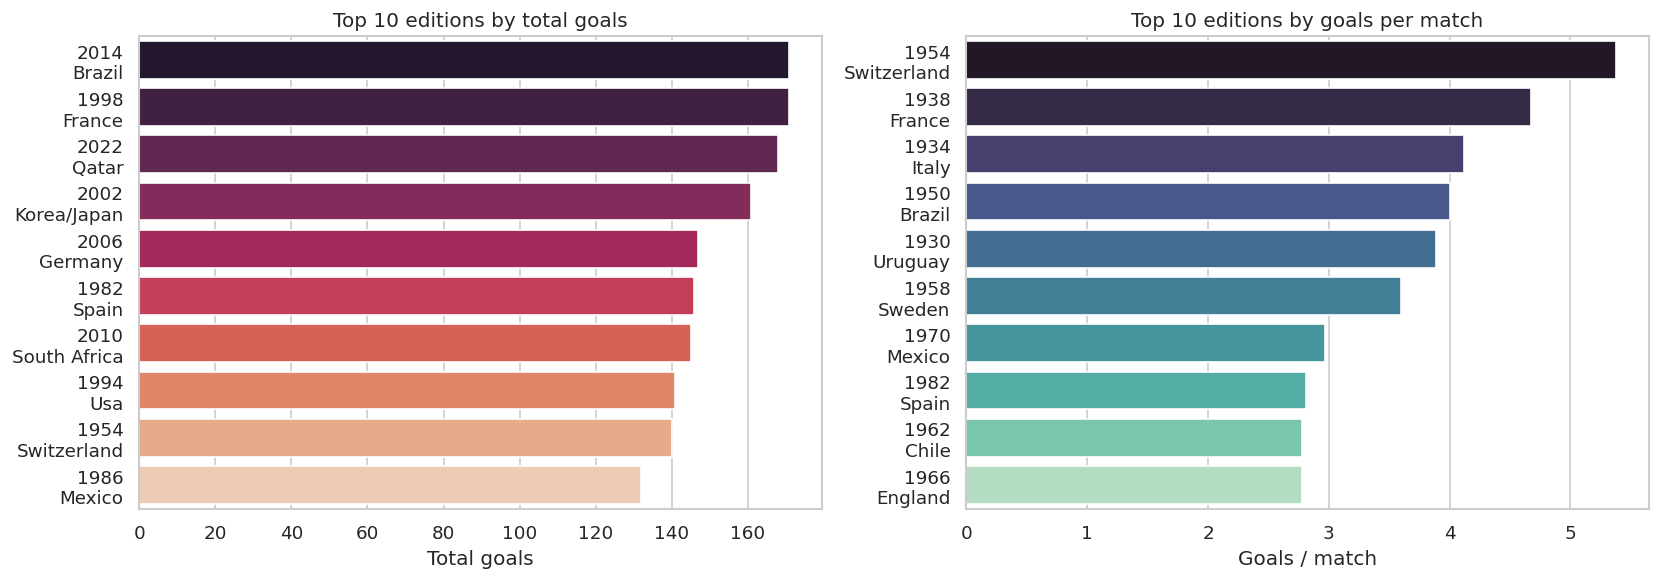

              edition_name  total_goals  n_matches  goals_per_match
edition_year                                                       
2014                Brazil        171.0         64             2.67
1998                France        171.0         64             2.67
2022                 Qatar        168.0         64             2.62
2002           Korea/Japan        161.0         64             2.52
2006               Germany        147.0         64             2.30
1982                 Spain        146.0         52             2.81
2010          South Africa        145.0         64             2.27
1994                   Usa        141.0         52             2.71
1954           Switzerland        140.0         26             5.38
1986                Mexico        132.0         52             2.54
1958                Sweden        126.0         35             3.60
1990                 Italy        115.0         52             2.21
1978             Argentina        102.0         

In [13]:
edition_stats = (
    matches.groupby(["edition_year", "edition_name"])["total_goals"]
    .agg(total_goals="sum", n_matches="count")
    .assign(goals_per_match=lambda d: (d["total_goals"] / d["n_matches"]).round(2))
    .reset_index()
    .sort_values("total_goals", ascending=False)
)
edition_stats["label"] = edition_stats["edition_year"].astype(str) + "\n" + edition_stats["edition_name"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_total = edition_stats.nlargest(10, "total_goals")
sns.barplot(x="total_goals", y="label", data=top_total, ax=axes[0], palette="rocket")
axes[0].set(title="Top 10 editions by total goals", xlabel="Total goals", ylabel="")

top_gpm = edition_stats.nlargest(10, "goals_per_match")
sns.barplot(x="goals_per_match", y="label", data=top_gpm, ax=axes[1], palette="mako")
axes[1].set(title="Top 10 editions by goals per match", xlabel="Goals / match", ylabel="")

plt.tight_layout()
plt.show()

print(edition_stats.set_index("edition_year")[["edition_name","total_goals","n_matches","goals_per_match"]].to_string())


## KPI 5 — 2022 World Cup: group stage goals & goal difference per team

/tmp/ipykernel_55834/1147325204.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=goals_by_group.index, y=goals_by_group.values, ax=axes[0], palette="Set2")


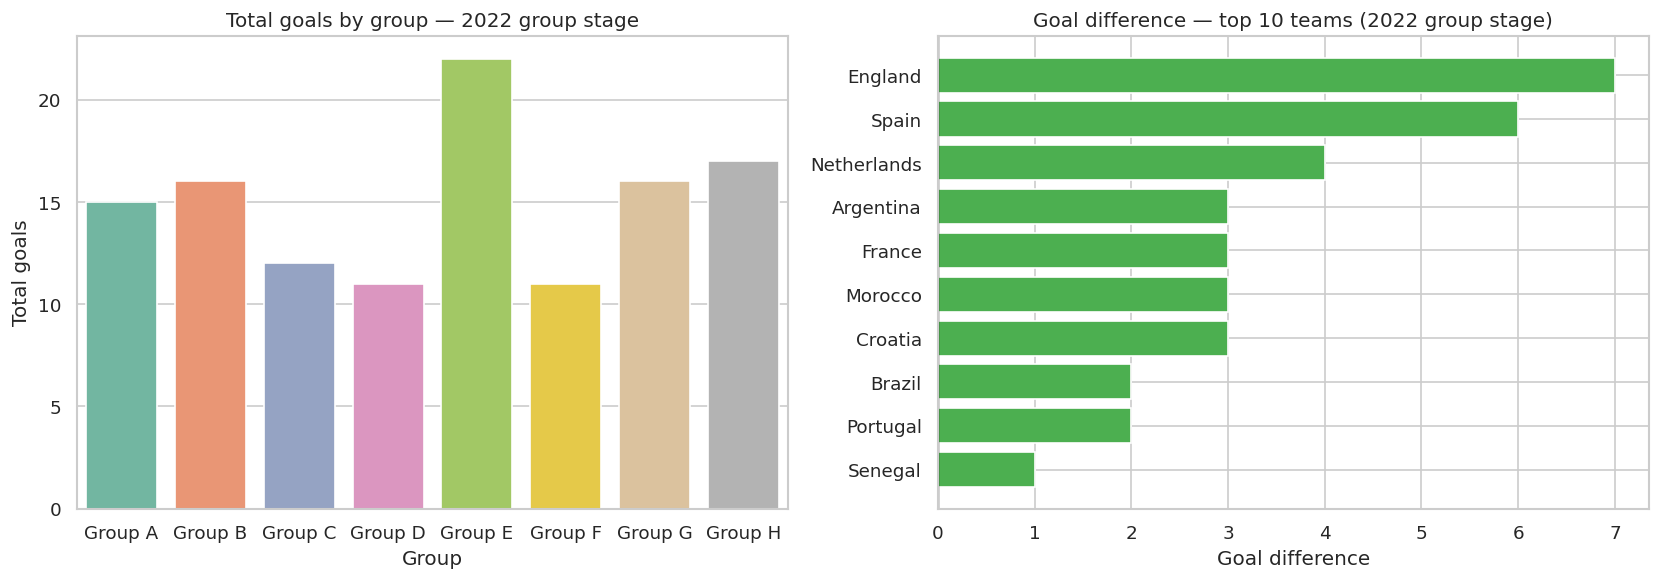

In [14]:
group_stage = matches[
    (matches["edition_year"] == 2022) &
    (matches["round"].str.startswith("Group"))
].copy()

# Goals per group (round column = "Group A", "Group B", …)
goals_by_group = group_stage.groupby("round")["total_goals"].sum().sort_index()

# Goal difference per team
gf = (pd.concat([
    group_stage.groupby("home_team")["home_result"].sum(),
    group_stage.groupby("away_team")["away_result"].sum()
]).groupby(level=0).sum())

ga = (pd.concat([
    group_stage.groupby("home_team")["away_result"].sum(),
    group_stage.groupby("away_team")["home_result"].sum()
]).groupby(level=0).sum())

gd = (gf - ga).sort_values(ascending=False).head(10).rename("goal_diff")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=goals_by_group.index, y=goals_by_group.values, ax=axes[0], palette="Set2")
axes[0].set(title="Total goals by group — 2022 group stage",
            xlabel="Group", ylabel="Total goals")

colors = ["#4CAF50" if v >= 0 else "#F44336" for v in gd.values]
axes[1].barh(gd.index[::-1], gd.values[::-1], color=colors[::-1])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set(title="Goal difference — top 10 teams (2022 group stage)",
            xlabel="Goal difference", ylabel="")

plt.tight_layout()
plt.show()
